In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

import sys, platform
print("Python:", sys.version)
print("OS:", platform.platform())

import shutil, os
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] += ";C:\\hadoop\\bin"
print("HADOOP_HOME: ", os.environ.get("HADOOP_HOME"))

python_path = sys.executable
os.environ['PYSPARK_PYTHON'] = python_path
os.environ['PYSPARK_DRIVER_PYTHON'] = python_path
print("PYSPARK_PYTHON: ", python_path)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.types import StringType
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer, IndexToString
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import re

Python: 3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]
OS: Windows-11-10.0.26200-SP0
HADOOP_HOME:  C:\hadoop
PYSPARK_PYTHON:  c:\Users\MSI-PC\miniconda3\envs\bigDataS7\python.exe


In [2]:
# 0. Setup Spark Session
print("\n0. SETUP SPARK SESSION...")
print("="*80)

spark = SparkSession.builder.appName("Tubes Project").getOrCreate()
spark


0. SETUP SPARK SESSION...


In [3]:
# 1. Load Preprocessed Dataset
print("\n1. LOAD PREPROCESSED DATA...")
print("="*80)

data_path = "../../data/processed/tubes/processed_flipkart.parquet"
df = spark.read.parquet(data_path)
df.show(5)

df.select(
    F.count(F.when(F.col("review_summary").isNull(), 1)).alias("null_clean"),
    F.count(F.when(F.col("review_summary") == "", 1)).alias("empty_clean"),
).show()




1. LOAD PREPROCESSED DATA...
+--------------------+-----+----+---------------+--------------------+--------------------+--------+----------+
|        product_name|price|rate|         review|             summary|      review_summary|rate_num|label_text|
+--------------------+-----+----+---------------+--------------------+--------------------+--------+----------+
|HP 680 Black Ink ...|852.0|   2|       Moderate|         Bad packing|moderate bad packing|     2.0|  negative|
|HP 680 Black Ink ...|852.0|   5|      Excellent|                Good|      excellent good|     5.0|  positive|
|HP 680 Black Ink ...|852.0|   5|      Excellent|It is a good prod...|excellent it is a...|     5.0|  positive|
|HP 680 Black Ink ...|852.0|   4|      Wonderful|Good product ???�...|wonderful good pr...|     4.0|  positive|
|HP 680 Black Ink ...|852.0|   1|Waste of money!|Not working bad p...|waste of money no...|     1.0|  negative|
+--------------------+-----+----+---------------+--------------------+----


2. BALANCE THE DATASET...


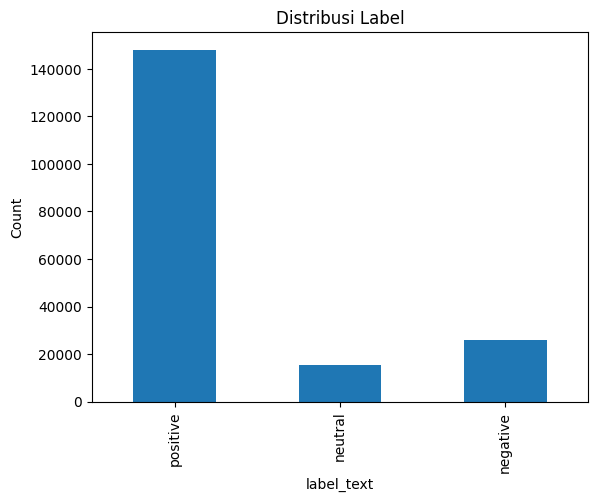

+----------+------+
|label_text| count|
+----------+------+
|  positive|148019|
|   neutral| 15642|
|  negative| 25758|
+----------+------+


 Jumlah data sebelum balancing: 189419


In [4]:
# 2. Balance the Dataset
print("\n2. BALANCE THE DATASET...")
print("="*80)

# Distribusi label sentimen
label_counts = df.groupBy("label_text").count().toPandas().set_index("label_text")
label_counts.plot(kind="bar", legend=False)
plt.title("Distribusi Label")
plt.ylabel("Count")
plt.show()

df = df.filter(F.col("label_text").isNotNull())
df.groupBy("label_text").count().show()

print("\n Jumlah data sebelum balancing:", df.count())

Dataset yang tidak seimbang dapat mengakibatkan model machine learning yang dilatih menjadi bias terhadap kelas mayoritas, yang berarti model cenderung mengabaikan kelas minoritas.

Mayoritas data berlabel/kelas "positive", sedangkan data dengan jumlah paling sedikit berlabel/kelas "neutral". Jumlah data disetiap kelas/label diseimbangkan dengan menurunkan jumlah data mayoritas "positive" (dan negative) menjadi sama jumlahnya dengan data "neutral" (*Undersampling*).


2.1. UNDERSAMPLE THE MAJORITY CLASSES...
Target (min count): 15642


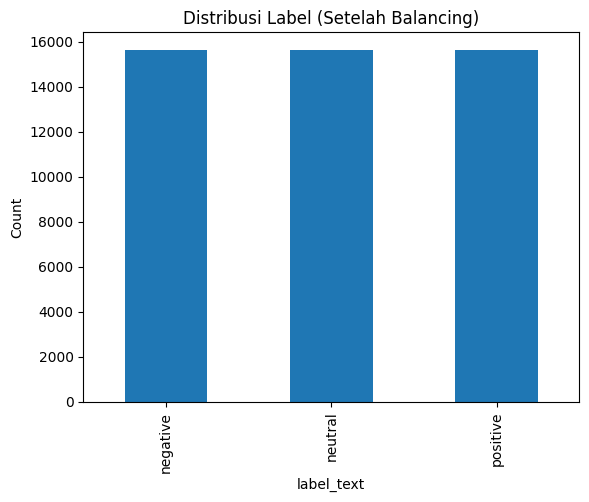

+----------+-----+
|label_text|count|
+----------+-----+
|  negative|15642|
|   neutral|15642|
|  positive|15642|
+----------+-----+


 Jumlah data setelah balancing (undersampling): 46926


In [5]:
# 2.1. Undersample kelas/label mayoritas
print("\n2.1. UNDERSAMPLE THE MAJORITY CLASSES...")
print("="*80)

# hitung jumlah per label
counts = (
        df.filter(F.col("label_text") != "positive")        # kecualikan positive
        .groupBy("label_text")
        .count()
        .toPandas()
        .set_index("label_text")["count"]
)
min_count = int(counts.min())
print("Target (min count):", min_count)

# tambahkan kolom random dan row_number per label
df_rand = df.withColumn("rand", F.rand(seed=42))
w = Window.partitionBy("label_text").orderBy(F.col("rand"))
df_ranked = df_rand.withColumn("rn", F.row_number().over(w))

# ambil top min_count untuk setiap label
df_balanced = df_ranked.filter(F.col("rn") <= min_count).drop("rand", "rn")
df = df_balanced


label_counts = df.groupBy("label_text").count().toPandas().set_index("label_text")
label_counts.plot(kind="bar", legend=False)
plt.title("Distribusi Label (Setelah Balancing)")
plt.ylabel("Count")
plt.show()

# cek
df.groupBy("label_text").count().orderBy("label_text").show()

print("\n Jumlah data setelah balancing (undersampling):", df.count())


In [6]:
# # SEKEDAR UNTUK TES PERBANDINGAN: 
# # Text cleaning (kolom review saja)
# df = df.withColumn("clean_review",
#     F.trim(
#         F.regexp_replace(
#             F.regexp_replace(
#                 F.regexp_replace(F.lower(F.col("review")), r"<.*?>", " "),      # remove HTML
#                 r"http\S+|www\S+|https\S+", " "),                               # remove URLs
#                 r"[^a-z0-9\s]", " ")                                            # keep alnum + space
#     )
# )

# # collapse multiple spaces
# df = df.withColumn("clean_review", F.regexp_replace(F.col("clean_review"), r"\s+", " ")) # replace multiple spaces with single space
# df.select("clean_review").show(10, truncate=200)

In [7]:
# # SEKEDAR UNTUK TES PERBANDINGAN: 
# # Text cleaning (kolom summary saja)
# df = df.withColumn("clean_summary",
#     F.trim(
#         F.regexp_replace(
#             F.regexp_replace(
#                 F.regexp_replace(F.lower(F.col("summary")), r"<.*?>", " "),     # remove HTML
#                 r"http\S+|www\S+|https\S+", " "),                               # remove URLs
#                 r"[^a-z0-9\s]", " ")                                            # keep alnum + space
#     )
# )

# # collapse multiple spaces
# df = df.withColumn("clean_summary", F.regexp_replace(F.col("clean_summary"), r"\s+", " ")) # replace multiple spaces with single space
# df.select("clean_summary").show(10, truncate=200)

In [8]:
# 3. Stopwords Removal
print("\n3. STOPWORDS REMOVAL...")
print("="*80)

# stopwords_list = [line.strip() for line in open("../../stopwords.txt", "r", encoding="utf-8")]

# Baca file stopwords
with open("../../stopwords.txt", "r", encoding="utf-8") as f:
    file_sw = [line.strip() for line in f if line.strip()]
# sumber stopwords: https://github.com/halxp1/sentiment-analysis/blob/master/english-sentiment-analysis/stopwords.txt

# Gabungkan dengan STOPWORDS dari wordcloud, pastikan semuanya lowercase
combined = set([w.lower() for w in file_sw]) | set([w.lower() for w in STOPWORDS])

# Konversi ke list (StopWordsRemover expects a list of strings)
stopwords_list = list(combined)

print("Total stopwords:", len(stopwords_list))

# StopWordsRemover expects a list
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens", stopWords=stopwords_list)


3. STOPWORDS REMOVAL...
Total stopwords: 901


In [9]:
# 4. Feature Extraction and Label Indexing
print("\n4. FEATURE EXTRACTION AND LABEL INDEXING...")
print("="*80)

# Pipeline fitur TF IDF dan label indexing
tokenizer = Tokenizer(inputCol="review_summary", outputCol="tokens")
hashingTF = HashingTF(inputCol="filtered_tokens", outputCol="rawFeatures", numFeatures=2**18)  # sesuaikan numFeatures jika tidak kuat
idf = IDF(inputCol="rawFeatures", outputCol="features")

label_indexer = StringIndexer(inputCol="label_text", outputCol="label").fit(df)
label_converter = IndexToString(inputCol="prediction", outputCol="predicted_label", labels=label_indexer.labels)


4. FEATURE EXTRACTION AND LABEL INDEXING...


In [10]:
# 5. Split Data and Define Baseline Model
print("\n5. SPLIT DATA AND DEFINE BASELINE MODEL...")
print("="*80)

# Split data dan definisikan model baseline
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count(), "Test:", test_df.count())

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100, regParam=0.01)
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, label_indexer, lr])


5. SPLIT DATA AND DEFINE BASELINE MODEL...
Train: 37665 Test: 9261


In [11]:
# 6. Train and Evaluate the Model
print("\n6. TRAIN AND EVALUATE THE MODEL...")
print("="*80)

model = pipeline.fit(train_df)


6. TRAIN AND EVALUATE THE MODEL...


In [12]:
pred = model.transform(test_df)
pred.show(10, truncate=150)

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
acc = evaluator_acc.evaluate(pred)
f1 = evaluator_f1.evaluate(pred)
print("Evaluation Metrics on Test Set:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (macro): {f1:.4f}")

# Macro F1 adalah cara mengukur performa klasifikasi multi‑kelas dengan menghitung F1 score untuk setiap kelas secara terpisah, lalu mengambil rata‑rata aritmetika dari nilai‑nilai tersebut

+-----------------------------------------------------------------------------------------------------------+-------+----+---------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+--------+----------+------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------

In [13]:
# confusion matrix
# conf_df = pred.groupBy("label_text", "predicted_label").count().toPandas()
conf_df = pred.groupBy("label", "prediction").count().toPandas()
print(conf_df)

# jika ingin matriks lengkap
labels = model.stages[-2].labels  # labels from StringIndexer
# Alternatif: gunakan sklearn confusion_matrix jika dataset kecil di driver
y_true = pred.select("label").toPandas()["label"]
y_pred = pred.select("prediction").toPandas()["prediction"]

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=labels))
print(confusion_matrix(y_true, y_pred))

   label  prediction  count
0    2.0         0.0     50
1    2.0         2.0   2546
2    2.0         1.0    471
3    1.0         1.0   2611
4    1.0         0.0    203
5    1.0         2.0    240
6    0.0         1.0    281
7    0.0         0.0   2805
8    0.0         2.0     54
              precision    recall  f1-score   support

    negative       0.92      0.89      0.91      3140
     neutral       0.78      0.85      0.81      3054
    positive       0.90      0.83      0.86      3067

    accuracy                           0.86      9261
   macro avg       0.86      0.86      0.86      9261
weighted avg       0.86      0.86      0.86      9261

[[2805  281   54]
 [ 203 2611  240]
 [  50  471 2546]]


In [14]:
# 7. Map Prediction to Labels for Visualization
print("\n7. MAP PREDICTION TO LABELS FOR VISUALIZATION...")
print("="*80)

labels = label_indexer.labels
print(labels)            # list urut: label untuk index 0,1,2,...

label_to_index = {lab: i for i, lab in enumerate(labels)}
index_to_label = {i: lab for i, lab in enumerate(labels)}
print("label -> index:", label_to_index)
print("index -> label:", index_to_label)

# Untuk visualisasi, map prediction ke prediction_label
# Karena label indexing berdasarkan label_text: 0=positive,, 1=negative, 2=neutral (urutan index tidak selalu sama)
pred = pred.withColumn(
    "prediction_label",
    F.when(F.col("prediction") == 0, labels[0])
     .when(F.col("prediction") == 1, labels[1])
     .when(F.col("prediction") == 2, labels[2])
     .otherwise(F.lit(None))
)

pred.groupBy("prediction_label").count().show()


7. MAP PREDICTION TO LABELS FOR VISUALIZATION...
['negative', 'neutral', 'positive']
label -> index: {'negative': 0, 'neutral': 1, 'positive': 2}
index -> label: {0: 'negative', 1: 'neutral', 2: 'positive'}
+----------------+-----+
|prediction_label|count|
+----------------+-----+
|        positive| 2840|
|         neutral| 3363|
|        negative| 3058|
+----------------+-----+



In [15]:
# Model dan hasil prediksi ini tidak perlu lagi disimpan, karena yang disimpan yang bagus aja (tuned model dan hasil prediksinya)

# # Simpan model
# model_path = "../../models/tubes/flipkart_sentiment_model"
# model.write().overwrite().save(model_path)

# # Simpan hasil prediksi sample ke Parquet/CSV (untuk analisis di notebook terpisah)
# pred.write.mode("overwrite").parquet("../../data/processed/tubes/predictions_flipkart.parquet")


8. ANALYSIS AND VISUALIZATION...

8.1. DISTRIBUSI LABEL TRAIN VS TEST...


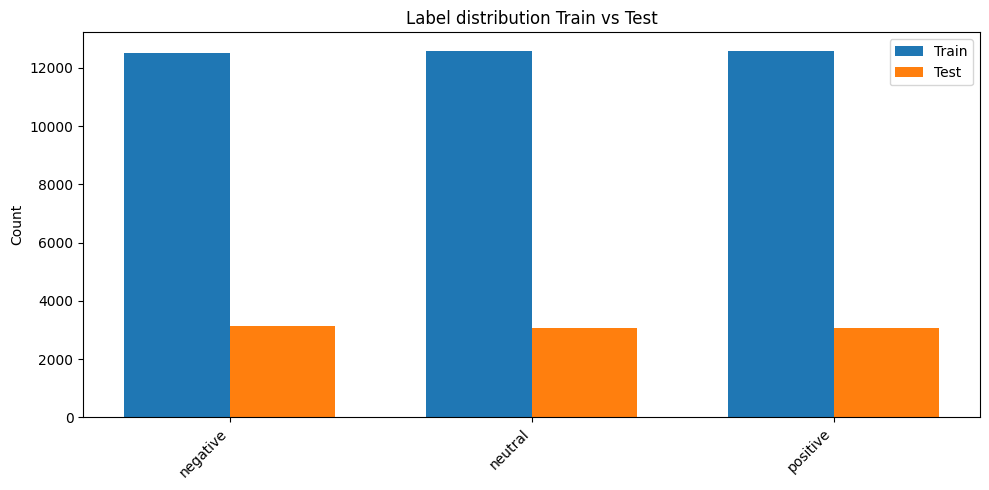

In [16]:
# 8. Analysis and Visualization
print("\n8. ANALYSIS AND VISUALIZATION...")
print("="*80)

# buat pred_train jika ingin bandingkan metrik train
try:
    pred_train = model.transform(train_df)
    pred_train = pred_train.withColumn(
        "prediction_label",
        F.when(F.col("prediction") == 0, labels[0])
        .when(F.col("prediction") == 1, labels[1])
        .when(F.col("prediction") == 2, labels[2])
        .otherwise(F.lit(None))
    )
    has_train = True
except Exception:
    pred_train = None
    has_train = False

# 8.1. Distribusi label Train vs Test ---
print("\n8.1. DISTRIBUSI LABEL TRAIN VS TEST...")

def spark_counts_to_pd(sdf, col="label_text"):
    return sdf.groupBy(col).count().toPandas().set_index(col)["count"].sort_index()

counts_train = spark_counts_to_pd(train_df, "label_text") if has_train else None
counts_test  = spark_counts_to_pd(test_df, "label_text")

all_labels = sorted(set(counts_test.index).union(set(counts_train.index) if counts_train is not None else set()))
if counts_train is not None:
    counts_train = counts_train.reindex(all_labels, fill_value=0)
counts_test = counts_test.reindex(all_labels, fill_value=0)

x = np.arange(len(all_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10,5))
if counts_train is not None:
    ax.bar(x - width/2, counts_train.values, width, label='Train', color='C0')
ax.bar(x + width/2 if counts_train is not None else x, counts_test.values, width if counts_train is not None else 0.6, label='Test', color='C1')
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Label distribution Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()



8.2. CONTOH TOKENISASI DAN DISTRIBUSI PANJANG TOKEN...
Contoh tokenisasi (sample):


,review_summary,tokens,filtered_tokens
0,nan very nice,"[nan, very, nice]",[nice]
1,nan nice looking,"[nan, nice, looking]",[nice]
2,nan superrrrrr awesome lovely fantastic fabulo...,"[nan, superrrrrr, awesome, lovely, fantastic, ...","[superrrrrr, awesome, lovely, fantastic, fabul..."
3,best in the market very nice product i like it...,"[best, in, the, market, very, nice, product, i...","[market, nice]"
4,terrific purchase never thought there would be...,"[terrific, purchase, never, thought, there, wo...","[terrific, purchase, flipkart, price, range, c..."
5,great product unbelievably easy worth buying h...,"[great, product, unbelievably, easy, worth, bu...","[unbelievably, easy, worth, buying, happy, cus..."
6,nan classy product from sonata very good looki...,"[nan, classy, product, from, sonata, very, goo...","[classy, sonata, easy, read, light, weight, bt..."
7,classy product installation was done on same d...,"[classy, product, installation, was, done, on,...","[classy, installation, day, jeeves, thanigaive..."
8,classy product good product,"[classy, product, good, product]",[classy]
9,mind blowing purchase very nice good product,"[mind, blowing, purchase, very, nice, good, pr...","[mind, blowing, purchase, nice]"


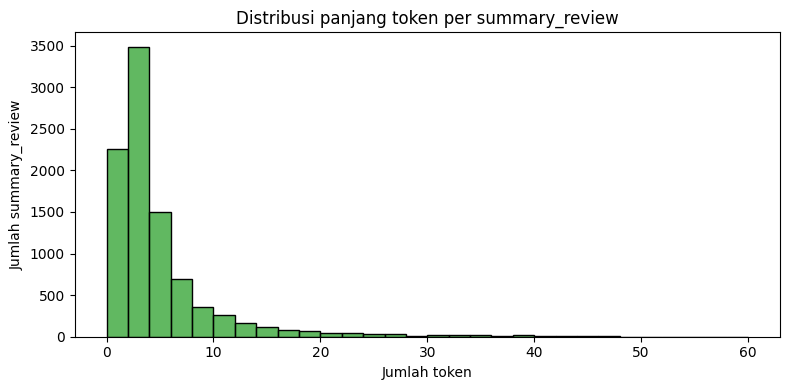

In [17]:
# 8.2. Contoh tokenisasi dan distribusi panjang token ---
print("\n8.2. CONTOH TOKENISASI DAN DISTRIBUSI PANJANG TOKEN...")

# ambil sample kecil untuk inspect tokens
sample_tokens = pred.select("review_summary", "tokens", "filtered_tokens").limit(200).toPandas()
print("Contoh tokenisasi (sample):")
display(sample_tokens.head(10))

# panjang token per summary_review (filtered_tokens jika ada)
if "filtered_tokens" in pred.columns:
    token_len_pd = pred.select(F.size(F.col("filtered_tokens")).alias("tok_len")).toPandas()
else:
    token_len_pd = pred.select(F.size(F.col("tokens")).alias("tok_len")).toPandas()

plt.figure(figsize=(8,4))
sns.histplot(token_len_pd['tok_len'], bins=30, kde=False, color='C2')
plt.title("Distribusi panjang token per summary_review")
plt.xlabel("Jumlah token")
plt.ylabel("Jumlah summary_review")
plt.tight_layout()
plt.show()

In [18]:
# 8.3. Top tokens per label ---
print("\n8.3. TOP TOKENS PER LABEL...")

# gunakan filtered_tokens jika tersedia, fallback ke split review_summary
if "filtered_tokens" in pred.columns:
    tokens_df = pred.select("label_text", F.explode(F.col("filtered_tokens")).alias("token"))
else:
    tokens_df = pred.select("label_text", F.explode(F.split(F.col("review_summary"), "\\s+")).alias("token"))

# filter token pendek dan stopwords sederhana
stopwords = ["yang","dan","di","ke","dari","ini","itu","untuk","dengan","pada","adalah","saya","kamu","dia","the","a","is"]
tokens_df = tokens_df.filter((F.col("token").isNotNull()) & (F.length(F.col("token")) > 2))
tokens_df = tokens_df.filter(~F.col("token").isin(stopwords))

top_tokens = tokens_df.groupBy("label_text", "token").count().orderBy(F.col("label_text"), F.desc("count")).toPandas()
top_per_label = top_tokens.groupby("label_text").head(15)
print("Top tokens per label (sample):")
display(top_per_label)


8.3. TOP TOKENS PER LABEL...
Top tokens per label (sample):


,label_text,token,count
0,negative,bad,823
1,negative,quality,787
2,negative,money,576
3,negative,waste,544
4,negative,poor,461
5,negative,worst,444
6,negative,don,413
7,negative,buy,340
8,negative,disappointed,291
9,negative,experience,218



8.4. TRAINING METRICS AND OBJECTIVE HISTORY...


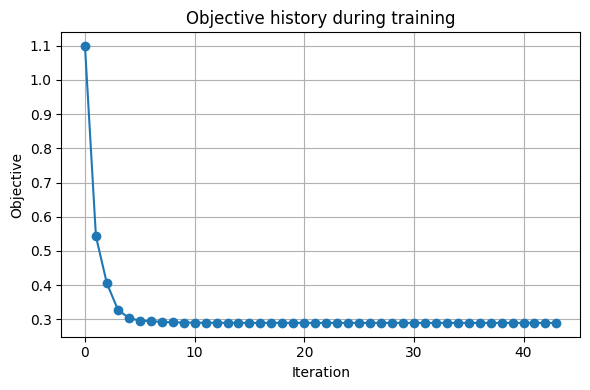

In [19]:
# 8.4. Training metrics and objective history ---
print("\n8.4. TRAINING METRICS AND OBJECTIVE HISTORY...")

# ambil lr model dari pipeline
lr_model = None
for s in model.stages:
    if s.__class__.__name__.endswith("LogisticRegressionModel"):
        lr_model = s
        break

if lr_model is not None:
    try:
        summary = lr_model.summary
        if summary is not None and hasattr(summary, "objectiveHistory"):
            obj = summary.objectiveHistory
            plt.figure(figsize=(6,4))
            plt.plot(obj, marker='o')
            plt.title("Objective history during training")
            plt.xlabel("Iteration")
            plt.ylabel("Objective")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    except Exception:
        pass


8.5. EVALUATE AND PRINT METRICS FOR TEST AND TRAIN...


Test  - Accuracy: 0.8597 | F1 (macro): 0.8607
Train - Accuracy: 0.9128 | F1 (macro): 0.9134


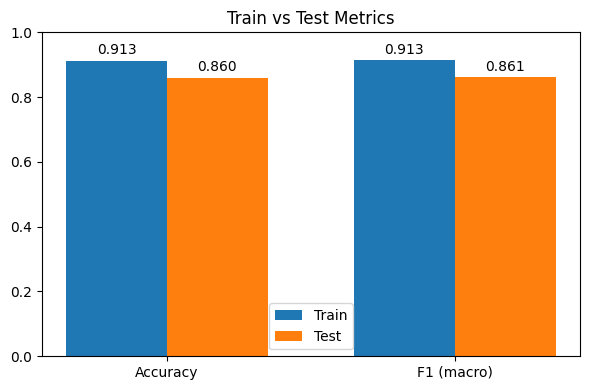

In [20]:
# 8.5. Evaluate and print metrics for test and train ---
print("\n8.5. EVALUATE AND PRINT METRICS FOR TEST AND TRAIN...")

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

acc_test = evaluator_acc.evaluate(pred)
f1_test  = evaluator_f1.evaluate(pred)
print(f"Test  - Accuracy: {acc_test:.4f} | F1 (macro): {f1_test:.4f}")

if has_train:
    acc_train = evaluator_acc.evaluate(pred_train)
    f1_train  = evaluator_f1.evaluate(pred_train)
    print(f"Train - Accuracy: {acc_train:.4f} | F1 (macro): {f1_train:.4f}")

# bar chart metrics
metrics_labels = ['Accuracy', 'F1 (macro)']
train_vals = [acc_train, f1_train] if has_train else [None, None]
test_vals  = [acc_test, f1_test]

fig, ax = plt.subplots(figsize=(6,4))
ind = np.arange(len(metrics_labels))
w = 0.35
if has_train:
    ax.bar(ind - w/2, train_vals, w, label='Train', color='C0')
ax.bar(ind + w/2 if has_train else ind, test_vals, w if has_train else 0.6, label='Test', color='C1')
ax.set_xticks(ind)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0,1)
ax.set_title('Train vs Test Metrics')
for i, v in enumerate(test_vals):
    ax.text(i + (w/2 if has_train else 0), v + 0.02, f"{v:.3f}", ha='center')
if has_train:
    for i, v in enumerate(train_vals):
        ax.text(i - w/2, v + 0.02, f"{v:.3f}", ha='center')
ax.legend()
plt.tight_layout()
plt.show()


8.6. CONFUSION MATRIX AND PER-CLASS METRICS FOR TEST SET...


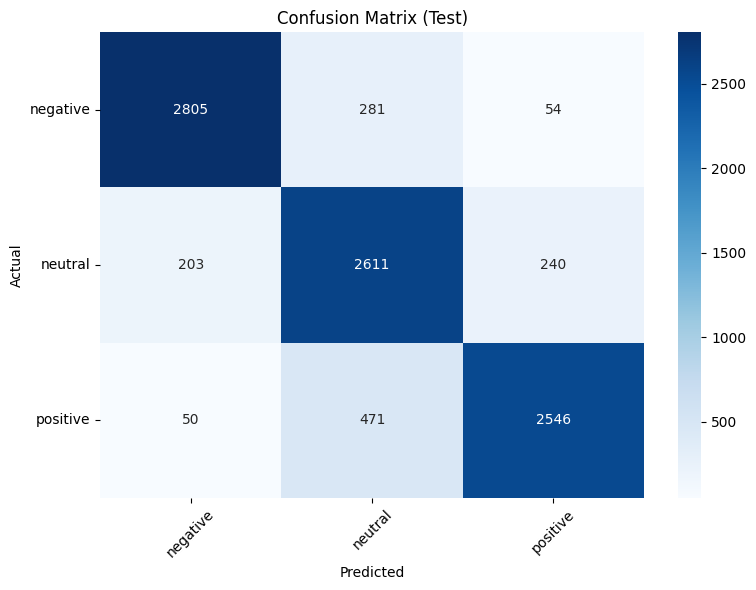

Per-class metrics (Test):


,precision,recall,f1,support
negative,0.9173,0.8933,0.9051,3140
neutral,0.7764,0.8549,0.8138,3054
positive,0.8965,0.8301,0.8620,3067


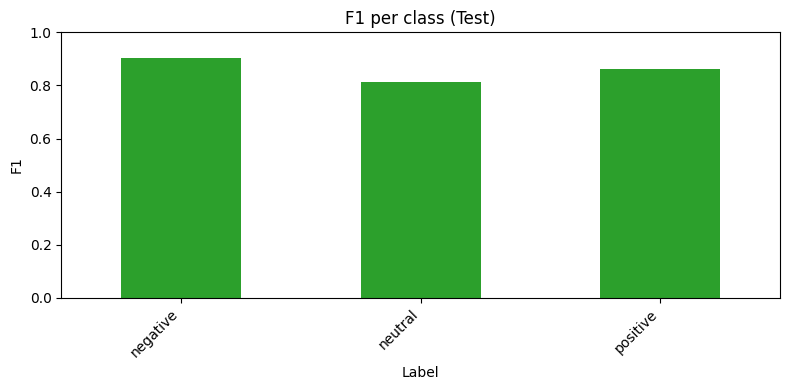

In [21]:
# 8.6. Confusion matrix and per-class metrics for test set ---
print("\n8.6. CONFUSION MATRIX AND PER-CLASS METRICS FOR TEST SET...")

cm_df = pred.groupBy("label_text", "prediction_label").count().toPandas()
cm_pivot = cm_df.pivot(index="label_text", columns="prediction_label", values="count").fillna(0).astype(int)
# ensure same order
cm_pivot = cm_pivot.reindex(index=all_labels, columns=all_labels, fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(cm_pivot, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# per-class precision recall f1 from confusion matrix
cm = cm_pivot.values
labels = cm_pivot.index.tolist()
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp+fp)!=0)
recall    = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0)
f1_per_class = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp, dtype=float), where=(precision+recall)!=0)

metrics_per_class = pd.DataFrame({
    "precision": np.round(precision,4),
    "recall": np.round(recall,4),
    "f1": np.round(f1_per_class,4),
    "support": cm.sum(axis=1)
}, index=labels)

print("Per-class metrics (Test):")
display(metrics_per_class)

fig, ax = plt.subplots(figsize=(8,4))
metrics_per_class["f1"].plot(kind="bar", color='C2', ax=ax)
ax.set_ylim(0,1)
ax.set_title("F1 per class (Test)")
ax.set_ylabel("F1")
ax.set_xlabel("Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


8.7. DISTRIBUTION OF ACTUAL VS PREDICTED LABELS...


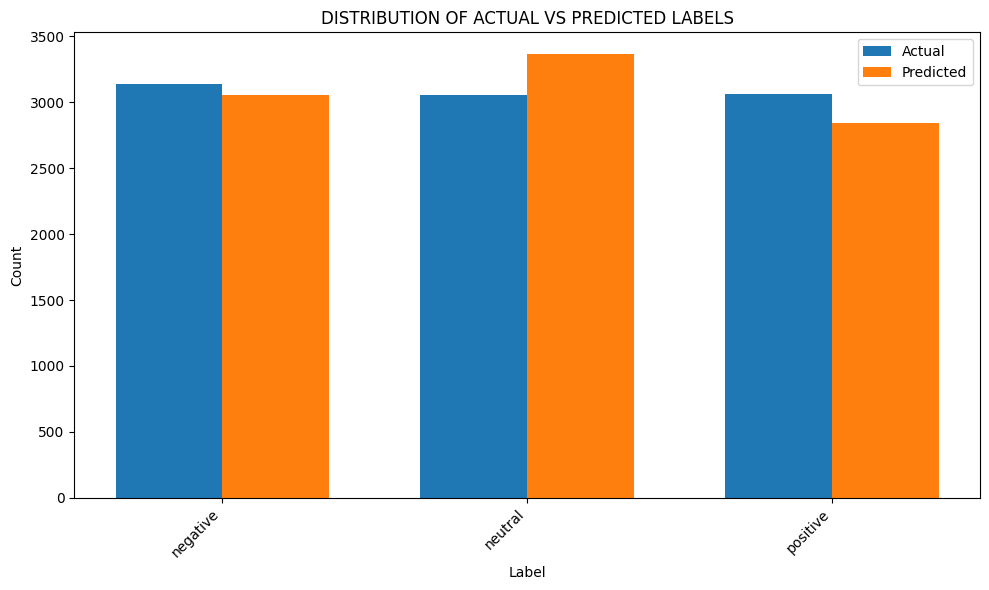

In [22]:
print("\n8.7. DISTRIBUTION OF ACTUAL VS PREDICTED LABELS...")
# Hitung frekuensi actual dan prediksi, konversi ke pandas Series
actual_pd = pred.groupBy("label_text").count().toPandas().set_index("label_text")["count"]
pred_pd   = pred.groupBy("prediction_label").count().toPandas().set_index("prediction_label")["count"]

# Samakan index (pastikan semua label muncul di kedua series)
all_labels = sorted(set(actual_pd.index).union(set(pred_pd.index)))
actual_pd = actual_pd.reindex(all_labels, fill_value=0)
pred_pd   = pred_pd.reindex(all_labels, fill_value=0)

# Siapkan posisi bar untuk grouped bar chart
labels = all_labels
x = np.arange(len(labels))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, actual_pd.values, width, label='Actual', color='C0')
ax.bar(x + width/2, pred_pd.values, width, label='Predicted', color='C1')

# Format sumbu dan label
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('DISTRIBUTION OF ACTUAL VS PREDICTED LABELS')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

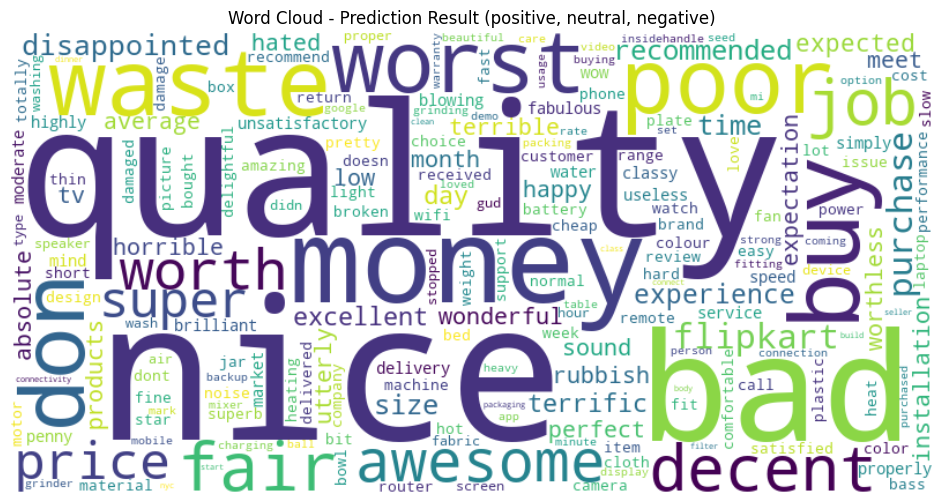

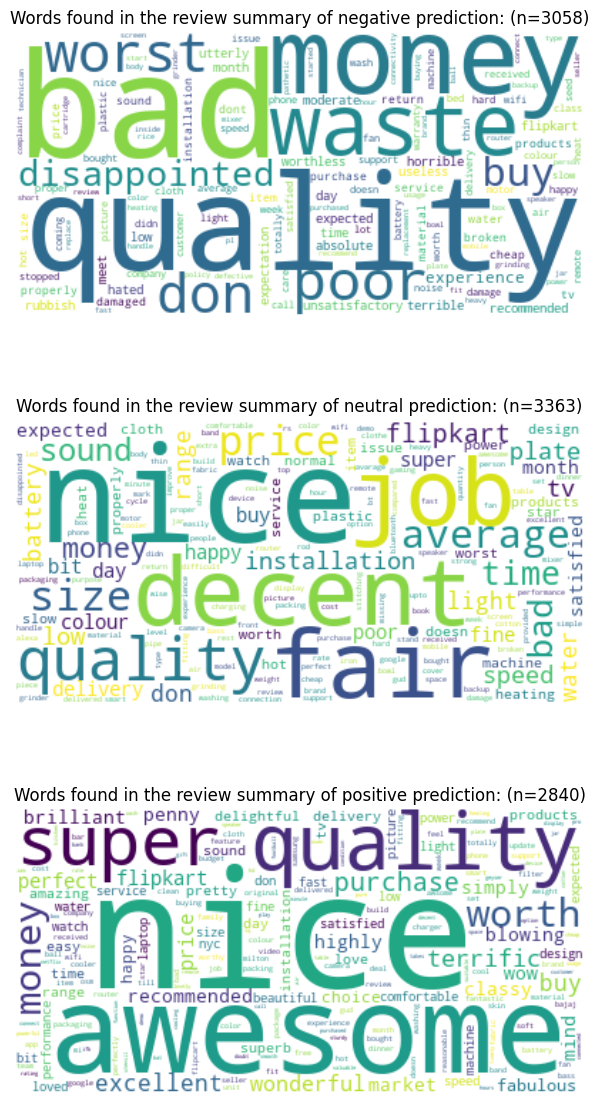

Saved: ../../images/tubes\wordcloud_all.png
Saved: ../../images/tubes\wordcloud_negative.png
Saved: ../../images/tubes\wordcloud_neutral.png
Saved: ../../images/tubes\wordcloud_positive.png


In [23]:
# Wordcloud untuk hasil prediksi (semua dan per label)

# Pilih kolom teks yang akan dipakai untuk wordcloud
# Preferensi: filtered_tokens -> tokens -> review_summary
if "filtered_tokens" in pred.columns:
    text_col = "filtered_tokens"
    # gabungkan token array menjadi string
    pred_text = pred.select("prediction_label", F.concat_ws(" ", F.col(text_col)).alias("text"))
elif "tokens" in pred.columns:
    text_col = "tokens"
    pred_text = pred.select("prediction_label", F.concat_ws(" ", F.col(text_col)).alias("text"))
else:
    text_col = "review_summary"
    pred_text = pred.select("prediction_label", F.col(text_col).alias("text"))

# Convert ke pandas (hanya kolom yang diperlukan)
pdf = pred_text.toPandas().dropna(subset=["text", "prediction_label"])
pdf["text"] = pdf["text"].astype(str)


# custom_stop = set(["product","good","use","like","one","would","also","get","really",])
# stopwords = STOPWORDS.union(custom_stop)

# WordCloud untuk semua prediksi gabungan
all_text = " ".join(pdf["text"].tolist())
wc_all = WordCloud(width=800, height=400, background_color="white",
                   stopwords=stopwords_list, collocations=False).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Prediction Result (positive, neutral, negative)")
plt.show()

# WordCloud per label (grid otomatis)
labels = sorted(pdf["prediction_label"].unique())
n = len(labels)
cols = 1
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

for i, lbl in enumerate(labels):
    texts = pdf.loc[pdf["prediction_label"] == lbl, "text"].tolist()
    if len(texts) == 0:
        wc = WordCloud(width=400, height=200, background_color="white", stopwords=stopwords_list).generate("")
    else:
        wc = WordCloud(width=400, height=200, background_color="white",
                       stopwords=stopwords_list, collocations=False).generate(" ".join(texts))
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Words found in the review summary of {lbl} prediction: (n={len(texts)})")
    axes[i].axis("off")

# hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Buat direktori output jika belum ada
out_dir = "../../images/tubes"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "wordcloud_all.png")

# Simpan gambar ke file
plt.imsave(out_path, wc_all.to_array())
print(f"Saved: {out_path}")

# buat dan simpan per-label dengan parameter eksplisit
for lbl in labels:
    texts = pdf.loc[pdf["prediction_label"] == lbl, "text"].tolist()
    combined_text = " ".join(texts).strip()
    # jika kosong, buat gambar kosong atau lewati
    if not combined_text:
        print(f"Label '{lbl}' kosong, lewati.")
        continue

    wc_lbl = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        collocations=False
    ).generate(combined_text)

    # sanitasi nama file (hapus/ubah karakter yang bermasalah)
    safe_lbl = "".join(c if c.isalnum() or c in (" ", "_", "-") else "_" for c in str(lbl)).strip().replace(" ", "_")
    out_path = os.path.join(out_dir, f"wordcloud_{safe_lbl}.png")

    # simpan ke file
    wc_lbl.to_file(out_path)
    print(f"Saved: {out_path}")